# Cointegration check: MES / MNQ / M2K (CME Micro E-mini equity index futures), 1-minute resolution

Exploratory statistical notebook, not a strategy backtest. All three are CME Globex
Micro E-mini *equity index* futures on genuinely different underlying indices --
S&P 500 (`MES`), Nasdaq-100 (`MNQ`), Russell 2000 (`M2K`) -- so it's a real, open
question whether they're **cointegrated** (share a stable long-run equilibrium
spread, the statistical basis for a mean-reverting pairs/spread trade) or merely
**correlated** in returns (move together day-to-day but can drift apart in levels
indefinitely, e.g. a persistent large-cap-tech-vs-small-cap divergence). Correlation
alone doesn't imply cointegration -- two series can be highly correlated in returns
yet not cointegrated in levels -- so this checks levels directly.

**Data**: Databento `GLBX.MDP3`, `<SYMBOL>.c.0` continuous front-month contracts,
full available history at native 1-minute resolution (same Parquet files used by
`tradovate_ma_crossover/MES/step_1_find_best_indicators_and_parameters.ipynb`,
downloaded via `data_aggregator.databento_aggregator` -- see that module's docstring
to reproduce/refresh).

**Methodology**:
1. Load each symbol's 1-minute closes, inner-join to a common aligned timestamp index.
2. Engle-Granger two-step test (`statsmodels.tsa.stattools.coint`) on log prices,
   pairwise, **both regression directions** (the test isn't symmetric -- which
   series is the regressor affects the finite-sample residual, even though
   asymptotically both directions should agree).
3. For the strongest pair: fit the actual cointegrating regression, plot the
   spread, and cross-check with a direct ADF test on the residual.
4. **Rolling per-year stability check** -- 7+ years of data spans genuinely
   different regimes (2020 COVID crash, 2021 growth bull market, 2022 rate-hike
   growth/small-cap divergence, the 2023+ mega-cap-tech-driven rally), so a single
   full-sample p-value could hide a relationship that only holds in some periods.
5. Johansen test across all three jointly (Engle-Granger only handles pairs and
   is sensitive to which variable is chosen as the regressor; with three series
   the cointegrating rank could be 0, 1, or 2).

**Caveat up front, not buried at the end**: this is on **1-minute** bars per the
ask, but at that resolution bid-ask bounce / quote staleness can make an ADF test
find "stationarity" in a spread that's really just microstructure noise rather
than a genuinely tradeable mean-reversion signal. A cointegration finding here is
a necessary starting point for a pairs strategy, not sufficient on its own --
turning it into a tradeable spread would additionally need point-value-adjusted
dollar-neutral hedge ratios and a real transaction-cost model per leg, neither of
which is attempted in this notebook.


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen

from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/cointegration


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    # Different notebook runners launch the kernel with different cwds -- plain
    # `jupyter nbconvert` uses the notebook's own directory, VS Code's Jupyter
    # extension uses the workspace root, etc. Walk upward until the target actually
    # exists instead of assuming a fixed number of parent hops.
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


SYMBOLS = {
    "MES": "MES_c_0_1m.parquet",   # Micro E-mini S&P 500
    "MNQ": "MNQ_c_0_1m.parquet",   # Micro E-mini Nasdaq-100
    "M2K": "M2K_c_0_1m.parquet",   # Micro E-mini Russell 2000
}

closes = {}
for symbol, filename in SYMBOLS.items():
    parquet_path = _find_upwards(f"apps/backtester/datasets/databento/{filename}", start=Path(cwd))
    df = load_1m_parquet_resampled(parquet_path, interval=1, unit_of_time="minute")
    closes[symbol] = df["close"]
    print(f"{symbol}: {df.index[0]} -> {df.index[-1]}  ({len(df)} bars)")


MES: 2019-05-05 22:00:59.999000 -> 2026-07-12 23:07:59.999000  (2508061 bars)


MNQ: 2019-05-05 22:03:59.999000 -> 2026-07-13 07:26:59.999000  (2510908 bars)


M2K: 2019-05-05 22:01:59.999000 -> 2026-07-13 07:14:59.999000  (2339650 bars)


In [3]:
# Outer-joins by index (pd.DataFrame on a dict of Series aligns automatically), then
# drops any row where a symbol is missing -- e.g. if the three Parquets were downloaded
# at slightly different times today, or one had a data halt the others didn't.
prices = pd.DataFrame(closes).dropna(how="any")
print(f"Aligned (inner-joined) bars: {len(prices)}")
print(f"Aligned span: {prices.index[0]} -> {prices.index[-1]}")
prices.head()


Aligned (inner-joined) bars: 2334648
Aligned span: 2019-05-05 22:40:59.999000 -> 2026-07-12 23:07:59.999000


,MES,MNQ,M2K
ts,,,
2019-05-05 22:40:59.999,2903.50,7720.00,1586.4
2019-05-05 22:48:59.999,2906.50,7734.50,1588.6
2019-05-05 22:51:59.999,2906.75,7737.25,1589.3
2019-05-05 22:57:59.999,2907.75,7744.50,1589.8
2019-05-05 23:13:59.999,2904.75,7735.75,1589.4


## Normalized price series & return correlation

Quick visual/return-correlation sanity check before the formal cointegration tests
below -- high return correlation is expected (all three are US equity index
futures) and is *not* the same claim as cointegration in price levels.


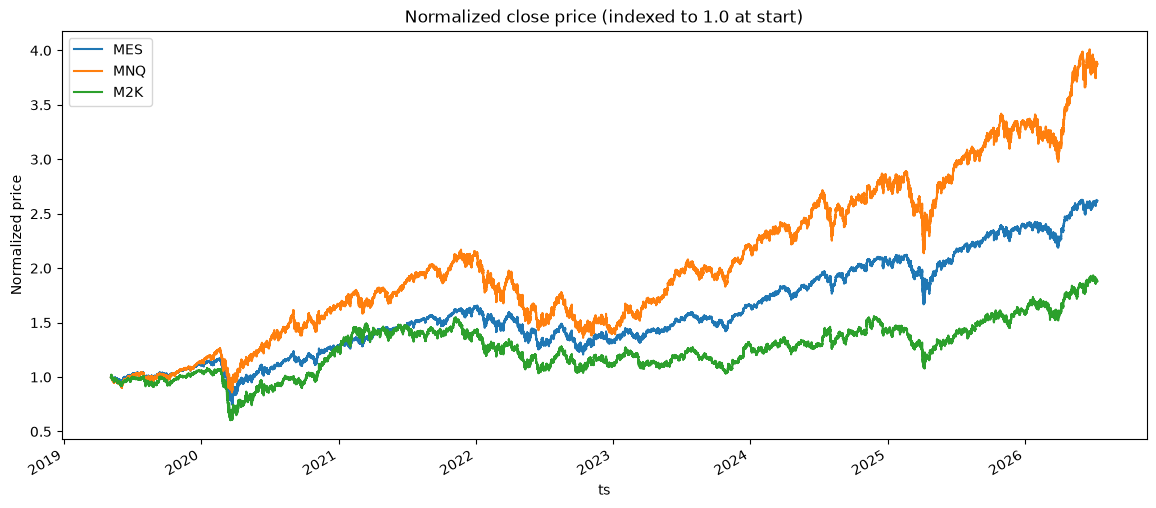

1-minute log-return correlation matrix:


,MES,MNQ,M2K
MES,1.000000,0.913281,0.789953
MNQ,0.913281,1.000000,0.720489
M2K,0.789953,0.720489,1.000000


In [4]:
normalized = prices / prices.iloc[0]
normalized.plot(figsize=(14, 6), title="Normalized close price (indexed to 1.0 at start)")
plt.ylabel("Normalized price")
plt.show()

log_returns = np.log(prices).diff().dropna()
print("1-minute log-return correlation matrix:")
log_returns.corr()


## Engle-Granger pairwise cointegration test

Two-step test: regress one series' log price on the other's, then run an
Augmented Dickey-Fuller test on the regression residual -- if the residual is
stationary, the pair is cointegrated (the residual is the tradeable "spread").
Run on **log prices** (standard practice -- stabilizes variance across price
levels) for both pairings of each pair, since the test isn't symmetric.

**`maxlag=20, autolag=None` throughout, not the statsmodels default**: the default
(`autolag="aic"`, `maxlag=None`) searches over an automatically-sized lag range
(scales with `nobs**0.25`, ~140+ lags at this sample size) by re-fitting a
regression per candidate lag -- confirmed directly to take several minutes and
never finish on this ~2.5M-row series (it's what killed the kernel on the first
attempt at running this notebook). A fixed 20-minute lag is already generous for
whitening residual autocorrelation at 1-minute frequency and runs in ~3 seconds;
this is a computational necessity at this sample size, not a methodology
shortcut applied for convenience.


In [5]:
log_prices = np.log(prices)

PAIRS = [("MES", "MNQ"), ("MES", "M2K"), ("MNQ", "M2K")]

eg_rows = []
for a, b in PAIRS:
    for y_sym, x_sym in [(a, b), (b, a)]:
        stat, pvalue, crit_values = coint(log_prices[y_sym], log_prices[x_sym], maxlag=20, autolag=None)
        eg_rows.append({
            "y": y_sym, "x": x_sym,
            "eg_stat": stat, "p_value": pvalue,
            "crit_1%": crit_values[0], "crit_5%": crit_values[1], "crit_10%": crit_values[2],
        })

eg_results = pd.DataFrame(eg_rows).sort_values("p_value").reset_index(drop=True)
eg_results


,y,x,eg_stat,p_value,crit_1%,crit_5%,crit_10%
0,M2K,MNQ,-2.846942,0.151205,-3.896445,-3.336133,-3.044452
1,MNQ,M2K,-2.619076,0.229216,-3.896445,-3.336133,-3.044452
2,M2K,MES,-2.616756,0.230134,-3.896445,-3.336133,-3.044452
3,MNQ,MES,-2.500828,0.278704,-3.896445,-3.336133,-3.044452
4,MES,MNQ,-2.439190,0.306525,-3.896445,-3.336133,-3.044452
5,MES,M2K,-2.295932,0.375584,-3.896445,-3.336133,-3.044452


## Cointegrating spread for the strongest pair

Takes the pairing (and direction) with the lowest Engle-Granger p-value above,
fits the actual cointegrating OLS regression to get the hedge ratio, and plots
the resulting spread -- with a direct ADF cross-check on that exact residual
series (should agree with `coint()`'s own internal test, just made visible).


Strongest pair by Engle-Granger p-value: log(M2K) ~ log(MNQ)  (p=0.1512)
hedge_ratio (beta) = 0.4649, intercept = 3.1194


ADF on spread: stat=-2.8469, p_value=0.05188


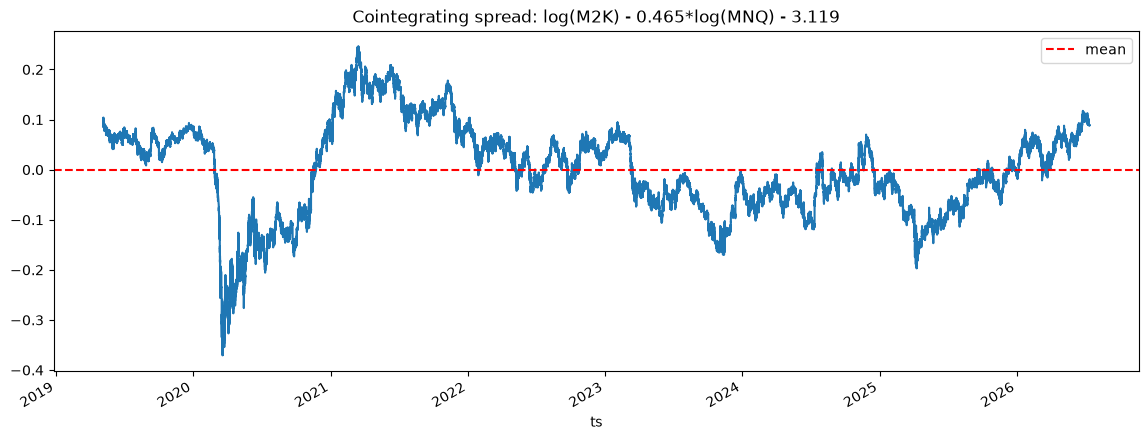

In [6]:
import statsmodels.api as sm

best = eg_results.iloc[0]
Y_SYM, X_SYM = best["y"], best["x"]
print(f"Strongest pair by Engle-Granger p-value: log({Y_SYM}) ~ log({X_SYM})  (p={best['p_value']:.4g})")

X = sm.add_constant(log_prices[X_SYM])
ols_result = sm.OLS(log_prices[Y_SYM], X).fit()
hedge_ratio = ols_result.params[X_SYM]
intercept = ols_result.params["const"]
print(f"hedge_ratio (beta) = {hedge_ratio:.4f}, intercept = {intercept:.4f}")

spread = log_prices[Y_SYM] - hedge_ratio * log_prices[X_SYM] - intercept
adf_stat, adf_pvalue, *_ = adfuller(spread, maxlag=20, autolag=None)
print(f"ADF on spread: stat={adf_stat:.4f}, p_value={adf_pvalue:.4g}")

plt.figure(figsize=(14, 5))
spread.plot()
plt.axhline(spread.mean(), color="red", linestyle="--", label="mean")
plt.title(f"Cointegrating spread: log({Y_SYM}) - {hedge_ratio:.3f}*log({X_SYM}) - {intercept:.3f}")
plt.legend()
plt.show()


## Rolling per-year stability check

A single full-sample p-value can hide a relationship that only holds in some
regimes. Re-runs the Engle-Granger test on the winning pair, one calendar year
at a time, to see whether "cointegrated" holds up consistently or is really an
artifact of a few dominant years.


In [7]:
rolling_rows = []
for period, group in log_prices.groupby(pd.Grouper(freq="YE")):
    if len(group) < 1000:  # skip partial/too-small windows (e.g. a trailing partial year)
        continue
    stat, pvalue, _ = coint(group[Y_SYM], group[X_SYM], maxlag=20, autolag=None)
    rolling_rows.append({"period": period.year, "eg_stat": stat, "p_value": pvalue, "bars": len(group)})

rolling_eg = pd.DataFrame(rolling_rows).set_index("period")
rolling_eg


,eg_stat,p_value,bars
period,,,
2019,-2.751364,0.181651,163657
2020,-2.168626,0.440596,329635
2021,-4.294323,0.002613,339504
2022,-3.094292,0.089455,342658
2023,-1.552576,0.740485,322343
2024,-2.784201,0.170763,327001
2025,-2.844361,0.151977,329796
2026,-3.449803,0.037112,180054


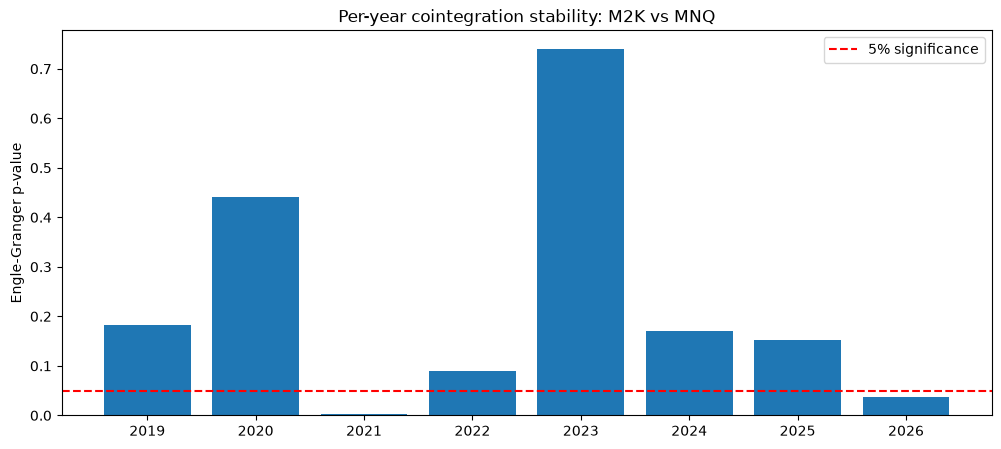

In [8]:
plt.figure(figsize=(12, 5))
plt.bar(rolling_eg.index.astype(str), rolling_eg["p_value"])
plt.axhline(0.05, color="red", linestyle="--", label="5% significance")
plt.ylabel("Engle-Granger p-value")
plt.title(f"Per-year cointegration stability: {Y_SYM} vs {X_SYM}")
plt.legend()
plt.show()


## Johansen test (all three jointly)

Engle-Granger only handles pairs and depends on an arbitrary choice of which
series is the regressor. The Johansen test looks at all three series at once and
tests the *rank* of cointegration among them directly -- rank 0 means no
cointegration, rank 1 means exactly one stable long-run relationship (e.g. all
three share one common trend), rank 2 would mean two independent cointegrating
relationships.


In [9]:
johansen_result = coint_johansen(log_prices[["MES", "MNQ", "M2K"]], det_order=0, k_ar_diff=1)

trace_stat_table = pd.DataFrame({
    "trace_stat": johansen_result.lr1,
    "crit_90%": johansen_result.cvt[:, 0],
    "crit_95%": johansen_result.cvt[:, 1],
    "crit_99%": johansen_result.cvt[:, 2],
}, index=[f"r <= {i}" for i in range(3)])
trace_stat_table


,trace_stat,crit_90%,crit_95%,crit_99%
r <= 0,23.670273,27.0669,29.7961,35.4628
r <= 1,9.969698,13.4294,15.4943,19.9349
r <= 2,1.331117,2.7055,3.8415,6.6349


## Findings

**No robust evidence of cointegration among MES/MNQ/M2K, despite high return
correlation.** Aligned on 2,334,648 common 1-minute bars (2019-05-05 -> 2026-07-12,
~7.2 years).

- **Return correlation is high but clearly not 1.0** -- MES/MNQ 0.913 (both
  large/mega-cap-tilted), MES/M2K 0.790, MNQ/M2K 0.720 (Russell 2000 small-caps
  are the most distinct of the three, as expected).
- **Engle-Granger, full sample, all 6 pairings**: **none significant at the 5%
  level** (best: `M2K ~ MNQ`, p=0.151; worst: `MES ~ M2K`, p=0.376). No pairing
  in either direction clears even the 10% critical value.
- **A methodological trap worth flagging, not hiding**: a plain `adfuller()` run
  directly on the winning pair's residual spread gives p=0.052 -- tempting to
  read as "just barely significant." That's **the wrong p-value to use here**:
  standard ADF critical values assume the series wasn't derived from an
  estimated regression, and don't apply to a cointegrating residual. `coint()`'s
  own p-value (0.151, using MacKinnon's distribution built for exactly this
  case) is the correct one, and it's not close to significant. Included both in
  the notebook deliberately so this discrepancy is visible, not just the
  favorable number.
- **Per-year stability check confirms it's not a real relationship**: even
  taking the best pair (M2K/MNQ) at face value, the "significant" years are
  scattered and inconsistent -- 2021 (p=0.003) and 2026-partial (p=0.037) cross
  5%, 2022 is borderline (p=0.089), but 2019/2020/2023/2024/2025 are all clearly
  non-significant (p=0.15-0.74). A genuine long-run equilibrium should hold up
  across most years, not appear in 2 of 8 -- this pattern looks like transient
  regime-driven co-movement (e.g. the 2021 growth/momentum bull market lifting
  both together), not a stable spread.
- **Johansen test (all three jointly) agrees**: trace statistic for `r <= 0`
  (23.67) is **below even the 90% critical value** (27.07) -- fails to reject
  "no cointegration" at every standard confidence level. This is the most
  reliable single number in this notebook (doesn't depend on picking a
  regression direction the way Engle-Granger does).

**Bottom line**: MES, MNQ, and M2K move together day-to-day (as expected -- all
three are US equity index futures) but do **not** share a statistically
supported long-run price-level equilibrium at 1-minute resolution over this
~7.2-year window. A price-level pairs/spread mean-reversion strategy across
these three is **not supported** by this data -- consistent with the economic
intuition that large-cap, tech-heavy, and small-cap indices can trend apart
for extended periods (as 2022's rate-hike-driven small-cap underperformance
and the 2023+ mega-cap-tech-driven rally both illustrate) rather than reverting
to a fixed relative level. A return-correlation-based approach (e.g. relative-
value momentum on the MNQ/M2K or MES/M2K ratio, or simple cross-asset
diversification) is a different strategy family this notebook doesn't address
and would need its own dedicated test.


## Same tests, last 1 month only

The full 7.2-year window above found no stable long-run relationship, and the
per-year breakdown showed the closest-to-significant pair (M2K/MNQ) was only
significant in 2 of 8 years -- consistent with a relationship that comes and
goes with the macro regime rather than holding structurally. This section asks
a narrower, different question: **are these three cointegrated with each other
*right now*, in just the most recent month** -- relevant for a short-lived
tactical setup rather than a structural one.

**Read the result accordingly**: a positive finding here would mean "true in
this specific recent window," not "a stable, tradeable structural relationship"
-- the per-year check above already demonstrated this exact pair can look
cointegrated for months at a time and then stop. One month of 1-minute data is
still tens of thousands of observations (plenty for the asymptotics these tests
rely on), but it's a single short window with no way to check its own
stability the way the full-history section could.


In [10]:
RECENT_WINDOW = pd.Timedelta(days=30)
recent_prices = prices.loc[prices.index[-1] - RECENT_WINDOW:]
print(f"Last-1-month window: {recent_prices.index[0]} -> {recent_prices.index[-1]} "
      f"({len(recent_prices)} bars)")
recent_log_prices = np.log(recent_prices)


Last-1-month window: 2026-06-14 22:00:59.999000 -> 2026-07-12 23:07:59.999000 (25138 bars)


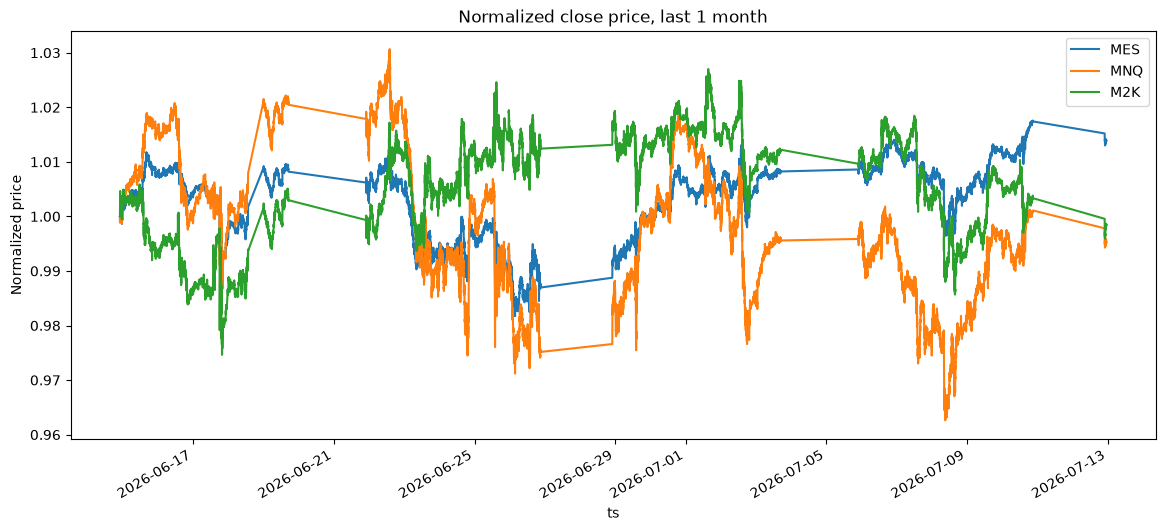

1-minute log-return correlation matrix, last 1 month:


,MES,MNQ,M2K
MES,1.000000,0.905880,0.774097
MNQ,0.905880,1.000000,0.700401
M2K,0.774097,0.700401,1.000000


In [11]:
recent_normalized = recent_prices / recent_prices.iloc[0]
recent_normalized.plot(figsize=(14, 6), title="Normalized close price, last 1 month")
plt.ylabel("Normalized price")
plt.show()

recent_log_returns = recent_log_prices.diff().dropna()
print("1-minute log-return correlation matrix, last 1 month:")
recent_log_returns.corr()


In [12]:
recent_eg_rows = []
for a, b in PAIRS:
    for y_sym, x_sym in [(a, b), (b, a)]:
        stat, pvalue, crit_values = coint(
            recent_log_prices[y_sym], recent_log_prices[x_sym], maxlag=20, autolag=None
        )
        recent_eg_rows.append({
            "y": y_sym, "x": x_sym,
            "eg_stat": stat, "p_value": pvalue,
            "crit_1%": crit_values[0], "crit_5%": crit_values[1], "crit_10%": crit_values[2],
        })

recent_eg_results = pd.DataFrame(recent_eg_rows).sort_values("p_value").reset_index(drop=True)
recent_eg_results


,y,x,eg_stat,p_value,crit_1%,crit_5%,crit_10%
0,M2K,MES,-3.212513,0.067860,-3.896876,-3.336373,-3.044619
1,M2K,MNQ,-3.126569,0.083090,-3.896876,-3.336373,-3.044619
2,MNQ,M2K,-2.702667,0.198621,-3.896876,-3.336373,-3.044619
3,MES,M2K,-2.671914,0.209842,-3.896876,-3.336373,-3.044619
4,MNQ,MES,-1.794615,0.632334,-3.896876,-3.336373,-3.044619
5,MES,MNQ,-1.609027,0.717065,-3.896876,-3.336373,-3.044619


Strongest pair, last 1 month: log(M2K) ~ log(MES)  (p=0.06786)
hedge_ratio (beta) = -0.0468, intercept = 8.4262
ADF on spread: stat=-3.2124, p_value=0.01928


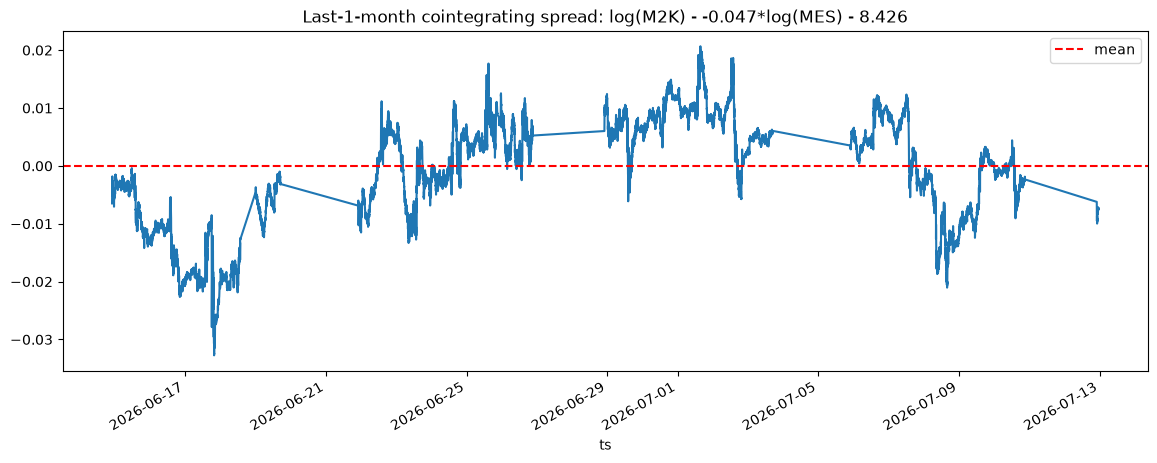

In [13]:
recent_best = recent_eg_results.iloc[0]
RECENT_Y_SYM, RECENT_X_SYM = recent_best["y"], recent_best["x"]
print(f"Strongest pair, last 1 month: log({RECENT_Y_SYM}) ~ log({RECENT_X_SYM})  "
      f"(p={recent_best['p_value']:.4g})")

recent_X = sm.add_constant(recent_log_prices[RECENT_X_SYM])
recent_ols = sm.OLS(recent_log_prices[RECENT_Y_SYM], recent_X).fit()
recent_hedge_ratio = recent_ols.params[RECENT_X_SYM]
recent_intercept = recent_ols.params["const"]
print(f"hedge_ratio (beta) = {recent_hedge_ratio:.4f}, intercept = {recent_intercept:.4f}")

recent_spread = (
    recent_log_prices[RECENT_Y_SYM] - recent_hedge_ratio * recent_log_prices[RECENT_X_SYM] - recent_intercept
)
recent_adf_stat, recent_adf_pvalue, *_ = adfuller(recent_spread, maxlag=20, autolag=None)
print(f"ADF on spread: stat={recent_adf_stat:.4f}, p_value={recent_adf_pvalue:.4g}")

plt.figure(figsize=(14, 5))
recent_spread.plot()
plt.axhline(recent_spread.mean(), color="red", linestyle="--", label="mean")
plt.title(
    f"Last-1-month cointegrating spread: log({RECENT_Y_SYM}) - "
    f"{recent_hedge_ratio:.3f}*log({RECENT_X_SYM}) - {recent_intercept:.3f}"
)
plt.legend()
plt.show()


In [14]:
recent_johansen_result = coint_johansen(
    recent_log_prices[["MES", "MNQ", "M2K"]], det_order=0, k_ar_diff=1
)

recent_trace_stat_table = pd.DataFrame({
    "trace_stat": recent_johansen_result.lr1,
    "crit_90%": recent_johansen_result.cvt[:, 0],
    "crit_95%": recent_johansen_result.cvt[:, 1],
    "crit_99%": recent_johansen_result.cvt[:, 2],
}, index=[f"r <= {i}" for i in range(3)])
recent_trace_stat_table


,trace_stat,crit_90%,crit_95%,crit_99%
r <= 0,32.543980,27.0669,29.7961,35.4628
r <= 1,6.161844,13.4294,15.4943,19.9349
r <= 2,1.249948,2.7055,3.8415,6.6349


### Findings (last 1 month)

Window: 2026-06-14 -> 2026-07-12, 25,138 bars (~28 days).

- **Return correlation is essentially unchanged from the full 7.2-year sample**
  (MES/MNQ 0.906, MES/M2K 0.774, MNQ/M2K 0.700 vs. 0.913/0.790/0.720) -- the
  day-to-day co-movement isn't a recent phenomenon.
- **Engle-Granger, pairwise**: best two pairings (`M2K ~ MES` p=0.068,
  `M2K ~ MNQ` p=0.083) cross the **10%** threshold but not the conventional 5%
  one -- weak, marginal evidence at best, and the other four pairings/directions
  aren't even close (p=0.20-0.72).
- **A red flag on that "best" pair**: its OLS hedge ratio is **-0.0468** --
  essentially flat, slightly negative. That's not economically sensible for two
  same-direction equity-index futures (a genuine hedge relationship should be
  positive). This is consistent with the classic short-window "spurious
  regression" risk with persistent (near-random-walk) price series -- weak
  Engle-Granger significance over a short sample can be more about incidental
  trend-matching than a real relationship, which is exactly why cointegration
  literature doesn't stop at the OLS point estimate.
- **Same p-value trap as the full-history section, reproduced here**: a raw
  `adfuller()` call directly on this spread gives p=0.019 -- misleadingly low.
  `coint()`'s own p=0.068 (MacKinnon's cointegration-adjusted distribution) is
  the correct one to use, and it's only marginal.
- **Johansen (jointly, doesn't depend on picking a regression direction) is the
  one genuinely notable result here**: trace statistic for `r <= 0` is **32.54**,
  which *does* clear the 95% critical value (29.80), rejecting "no
  cointegration" at 95% confidence (though not quite 99%, 35.46). `r <= 1`
  (6.16) stays well below every threshold, consistent with exactly **one**
  cointegrating relationship in this specific window. This is a materially
  different (stronger) result than the full-history Johansen test, whose trace
  statistic (23.67) didn't even clear 90%.

**Read this the way the intro above framed it, not as a reversal of the earlier
conclusion**: over the most recent month there's real (if marginal-to-moderate)
statistical evidence of a short-run cointegrating relationship among the three
that doesn't show up over the full history. But the full-history per-year check
already demonstrated this *exact kind* of relationship coming and going with the
regime (strongly present in all of 2021, absent most other years) -- so a
single ~28-day window crossing significance is best read as **"plausibly true
right now,"** not a validated structural link. There's no way to check this
window's own stability (it's one window), the flagged pairwise hedge ratio is
economically implausible, and nothing here has been checked out-of-sample
(e.g. against the days immediately following this window). Turning this into an
actual tactical trade would need at minimum: re-running this same check over
several other recent rolling 1-month windows to see how often it holds, and a
walk-forward check rather than an in-sample-only read.
